In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import *
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [2]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

In [3]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [4]:
df["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [ ]:
X = df.drop("target",axis=1)
y = df["target"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)


In [ ]:
model = KNeighborsClassifier(n_neighbors=3) # n_neighbors = 5 default

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [14]:
acc = accuracy_score(y_test, y_pred)

print(acc)


1.0


In [15]:
report = classification_report(y_test, y_pred, output_dict=True)

metrics_df = pd.DataFrame(report).transpose()
print(metrics_df)

              precision  recall  f1-score  support
0                   1.0     1.0       1.0     19.0
1                   1.0     1.0       1.0     13.0
2                   1.0     1.0       1.0     13.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0     45.0
weighted avg        1.0     1.0       1.0     45.0


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA

In [19]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

X = df.drop("target", axis=1)
y = df["target"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [23]:
# Fit model on PCA 2D features
model_pca = KNeighborsClassifier(n_neighbors=3)
model_pca.fit(X_train_pca, y_train)

# Use model_pca for prediction on meshgrid
Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

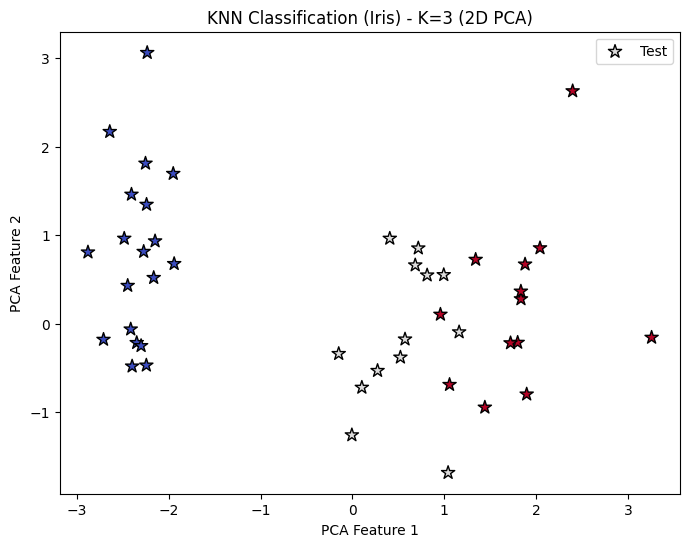

In [26]:
# Fit KNN on 2D PCA data
model_pca = KNeighborsClassifier(n_neighbors=3)
model_pca.fit(X_train_pca, y_train)

# Predict on meshgrid
# Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
# Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
# plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
# plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=50, cmap=plt.cm.coolwarm, edgecolor='k', label='Train')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, s=100, marker='*', cmap=plt.cm.coolwarm, edgecolor='k', label='Test')
plt.title("KNN Classification (Iris) - K=3 (2D PCA)")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.legend()
plt.show()